# **Summer School Sustainable Digital Finance** - Introduction to Python - 2
Author: Nicole Bellert - bell@zhaw.ch


---------------------------------------------


In this exercise, we will analyze stock market data from Yahoo Finance.

In [1]:
#!pip install yfinance

In [39]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf

**Section:** Fetching Stock Data with YFinance

In [40]:
# Assign a ticker
apple = yf.Ticker("AAPL")
apple.sustainability
# esg_data = pd.DataFrame.transpose(apple.sustainability)
# esg_data['company_ticker'] = str(apple.ticker)

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: AAPL"}}}


""


In [41]:
# yf.Ticker("NVDA").sustainability
# Fallback method if the sustainability DataFrame is blank
info_dict = yf.Ticker("AAPL").info
total_esg = info_dict.get('totalEsg') 
print(total_esg)
print(info_dict)
# yf.Ticker("SPCX").sustainability
governance_metrics = {
    "Audit Risk": info_dict.get("auditRisk"),
    "Board Risk": info_dict.get("boardRisk"),
    "Compensation Risk": info_dict.get("compensationRisk"),
    "Shareholder Rights Risk": info_dict.get("shareHolderRightsRisk"),
    "Overall Governance Risk": info_dict.get("overallRisk")
}

for metric, score in governance_metrics.items():
    print(f"{metric}: {score}")


None
{'address1': 'One Apple Park Way', 'city': 'Cupertino', 'state': 'CA', 'zip': '95014', 'country': 'United States', 'phone': '(408) 996-1010', 'website': 'https://www.apple.com', 'industry': 'Consumer Electronics', 'industryKey': 'consumer-electronics', 'industryDisp': 'Consumer Electronics', 'sector': 'Technology', 'sectorKey': 'technology', 'sectorDisp': 'Technology', 'longBusinessSummary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allows customers to discover and download applicatio

In [42]:
gold = yf.Ticker("GC=F")

In [43]:
# Get data
startDate = "2020-01-01"
endDate = "2020-12-31"
apple_df = apple.history(start=startDate, end=endDate)
apple_df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-01-02 00:00:00-05:00,71.282605,72.331732,71.029953,72.271576,135480400,0.0,0.0
2020-01-03 00:00:00-05:00,71.501542,72.326882,71.345137,71.568916,146322800,0.0,0.0
2020-01-06 00:00:00-05:00,70.693051,72.177699,70.442799,72.139198,118387200,0.0,0.0
2020-01-07 00:00:00-05:00,72.148820,72.403881,71.580950,71.799919,108872000,0.0,0.0
2020-01-08 00:00:00-05:00,71.503945,73.255691,71.503945,72.954910,132079200,0.0,0.0
...,...,...,...,...,...,...,...
2020-12-23 00:00:00-05:00,128.302252,128.564360,126.962530,127.137283,88223700,0.0,0.0
2020-12-24 00:00:00-05:00,127.486777,129.564310,127.273198,128.117798,54930100,0.0,0.0
2020-12-28 00:00:00-05:00,130.078798,133.331002,129.612799,132.699982,124486200,0.0,0.0


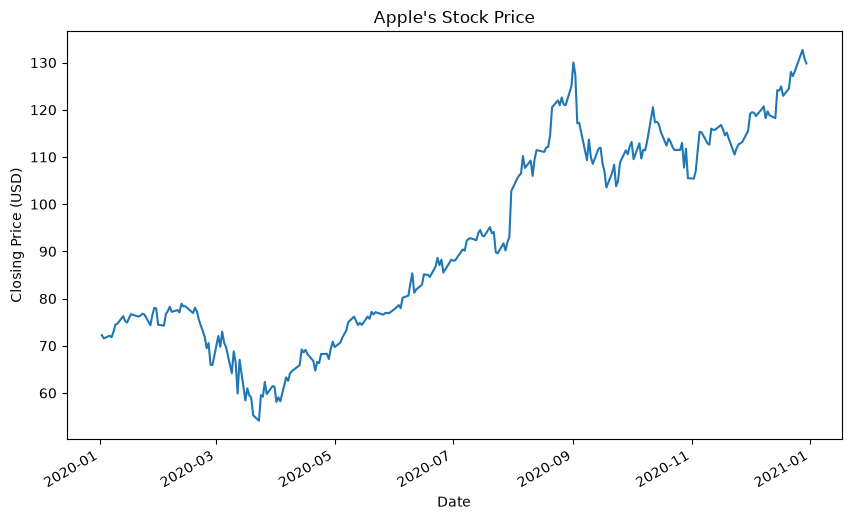

In [44]:
# Plots
apple_df["Close"].plot(figsize=(10, 6), title="Apple's Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.show()

In [45]:
# Fetching Multiple Stocks
multi_data = yf.download(["AAPL", "MSFT"], start="2020-01-01", end="2021-01-01")
multi_data.head()

[*********************100%***********************]  2 of 2 completed


Price           Close                   High                    Low  \
Ticker           AAPL        MSFT       AAPL        MSFT       AAPL   
Date                                                                  
2020-01-02  72.271545  151.544296  72.331702  151.648081  71.029923   
2020-01-03  71.568909  149.657242  72.326874  150.912092  71.345130   
2020-01-06  72.139191  150.044128  72.177691  150.110180  70.442792   
2020-01-07  71.799942  148.675995  72.403904  150.647897  71.580973   
2020-01-08  72.954926  151.044205  73.255706  151.714093  71.503960   

Price                        Open                 Volume            
Ticker            MSFT       AAPL        MSFT       AAPL      MSFT  
Date                                                                
2020-01-02  149.383697  71.282575  149.808267  135480400  22622100  
2020-01-03  149.128887  71.501534  149.374205  146322800  21116200  
2020-01-06  147.666515  70.693043  148.204315  118387200  20813700  
2020-01-07  148.430691  72.148843  150.317682  108872000  21634100  
2020-01-08  149.025125  71.503960  149.949746  132079200  27746500

In [46]:
# Interval-based Data Retrieval
# Valid intervals: [1m, 2m, 5m, 15m, 30m, 60m, 90m, 1h, 1d, 5d, 1wk, 1mo, 3mo]')
# Note: minutes and horly data have a time limit!
apple_weekly = yf.download("AAPL", start="2020-01-01", end="2021-01-01", interval="1wk")
apple_weekly.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-01,71.799919,72.403881,70.442794,71.282571,509062400
2020-01-08,75.238449,76.415106,71.503960,71.503960,726318800
2020-01-15,76.174484,76.764010,74.485296,75.038737,479412400
2020-01-22,76.443977,77.801095,73.361579,76.658129,677016000
2020-01-29,76.723091,78.888711,72.721506,78.070589,852965600
2020-02-05,77.088493,78.441604,75.699212,78.031569,545608400
2020-02-12,76.941376,78.924003,75.882524,77.537129,441122800
2020-02-19,69.483589,78.304109,69.013262,77.182552,776972800


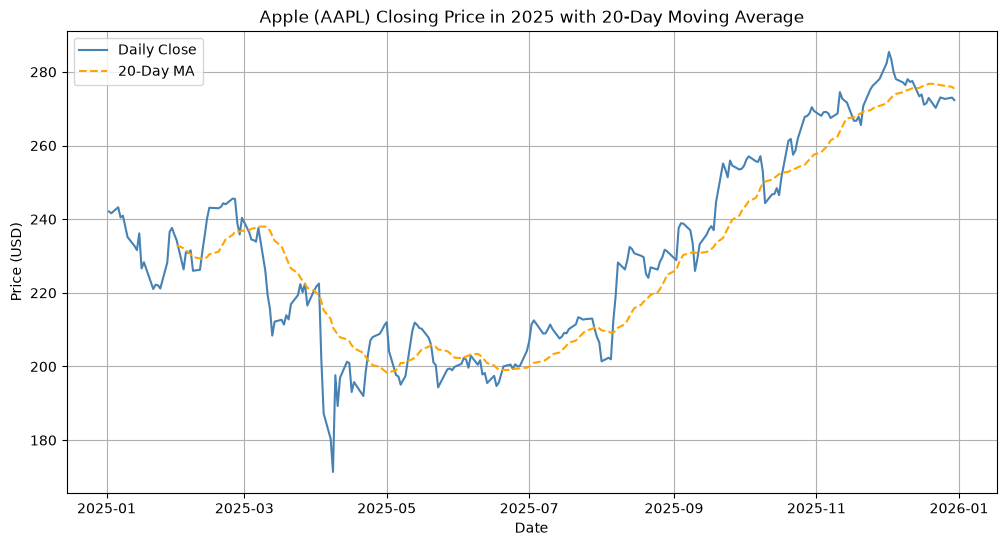

In [47]:
# Adding Moving Average indicators
apple = yf.Ticker("AAPL")
apple_df = apple.history(start="2025-01-01", end="2025-12-31")

# Add a 20-day moving average
apple_df["MA20"] = apple_df["Close"].rolling(window=20).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(apple_df["Close"], label="Daily Close", color="steelblue")
plt.plot(apple_df["MA20"], label="20-Day MA", color="orange", linestyle="--")
plt.title("Apple (AAPL) Closing Price in 2025 with 20-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

#### Interpretation:
- The **closing price** curve shows Apple’s performance across 2025.
- The **20-day moving average** smooths short-term fluctuations and highlights medium-term trends.
- This type of analysis is commonly used in **technical analysis** and **trading strategy development**. But, could be used in regression analysis as well!

### Load MICROSOFT (MSFT) stock prices.

In [48]:
ticker = "MSFT"
msft = yf.Ticker(ticker)
df = msft.history(start="2010-12-31", interval="1d")
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-12-31 00:00:00-05:00,21.074946,21.165918,20.946070,21.158337,24752000,0.0,0.0
2011-01-03 00:00:00-05:00,21.264471,21.363024,21.165920,21.211405,53443800,0.0,0.0
2011-01-04 00:00:00-05:00,21.181081,21.355441,21.112852,21.294794,54405600,0.0,0.0
2011-01-05 00:00:00-05:00,21.150759,21.234149,21.052207,21.226568,58998700,0.0,0.0
2011-01-06 00:00:00-05:00,21.256889,21.870943,21.120433,21.848200,88026300,0.0,0.0


In [49]:
# First 6 and 6 entries
df.head(6)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-12-31 00:00:00-05:00,21.074946,21.165918,20.946070,21.158337,24752000,0.0,0.0
2011-01-03 00:00:00-05:00,21.264471,21.363024,21.165920,21.211405,53443800,0.0,0.0
2011-01-04 00:00:00-05:00,21.181081,21.355441,21.112852,21.294794,54405600,0.0,0.0
2011-01-05 00:00:00-05:00,21.150759,21.234149,21.052207,21.226568,58998700,0.0,0.0
2011-01-06 00:00:00-05:00,21.256889,21.870943,21.120433,21.848200,88026300,0.0,0.0
2011-01-07 00:00:00-05:00,21.711746,21.787556,21.416091,21.681423,73762000,0.0,0.0


In [50]:
df.tail(6)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-25 00:00:00-04:00,485.440002,492.440002,484.299988,491.709991,19519000,0.0,0.0
2026-08-26 00:00:00-04:00,487.850006,497.399994,487.309998,496.369995,20758900,0.0,0.0
2026-08-27 00:00:00-04:00,494.880005,506.480011,490.079987,505.059998,28688800,0.0,0.0
2026-08-28 00:00:00-04:00,505.329987,517.780029,504.869995,513.530029,29207300,0.0,0.0
2026-08-31 00:00:00-04:00,510.380005,512.190002,506.390015,507.290009,27208900,0.0,0.0
2026-09-01 00:00:00-04:00,497.519989,505.970001,496.779999,501.019989,21032500,0.0,0.0


In [51]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3940.000000,3940.000000,3940.000000,3940.000000,3.940000e+03,3940.000000,3940.0
mean,168.282647,169.890672,166.616778,168.324275,3.356786e+07,0.007746,0.0
std,151.851923,153.244597,150.391870,151.867711,1.886310e+07,0.066823,0.0
min,18.229812,18.429382,18.153055,18.199099,5.855900e+06,0.000000,0.0
25%,37.491925,37.774154,37.195446,37.493780,2.173425e+07,0.000000,0.0
50%,99.673383,100.620485,98.252740,99.582825,2.854685e+07,0.000000,0.0
75%,281.193167,283.992682,278.634945,282.227303,3.963800e+07,0.000000,0.0
max,549.795172,550.013050,536.356983,537.646362,3.193179e+08,0.910000,0.0


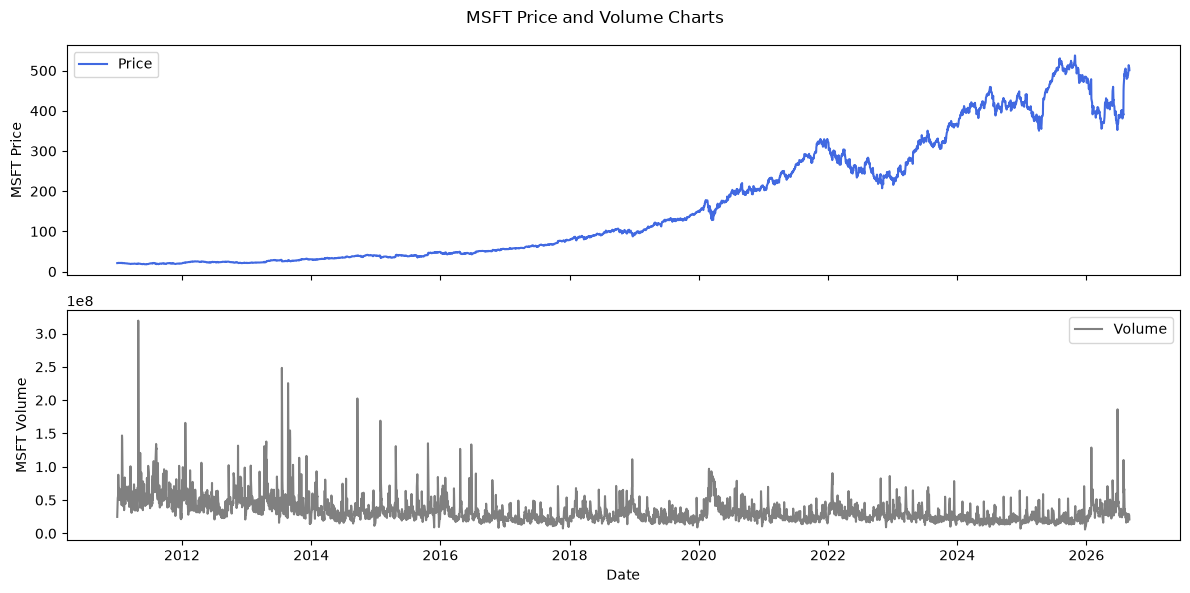

In [52]:
# Plot
fig, axs = plt.subplots(2, figsize=(12, 6), sharex=True)
fig.suptitle(f"{ticker} Price and Volume Charts")
axs[0].plot(df.index, df["Close"], label="Price", color="royalblue")
axs[0].set_ylabel("MSFT Price")
axs[0].legend()
axs[1].plot(df.index, df["Volume"], label="Volume", color="gray")
axs[1].set_ylabel("MSFT Volume")
axs[1].legend()
plt.xlabel("Date")
plt.tight_layout()
plt.show()

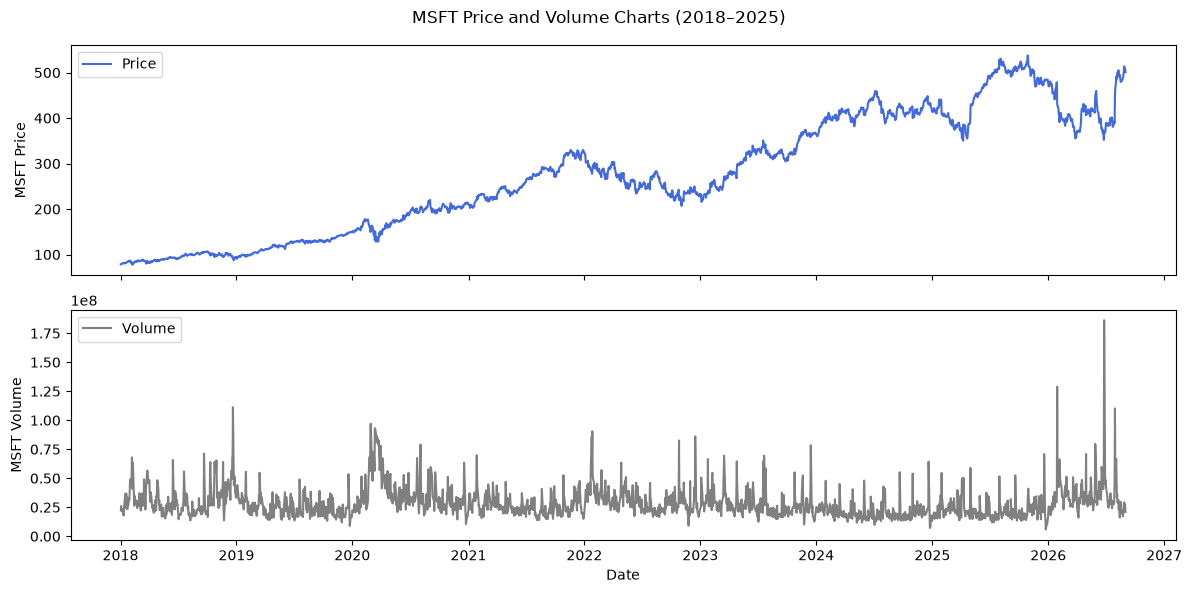

In [53]:
# Filter data from 2018 onwards
df_filtered = df[df.index >= "2018-01-01"]

# Plot price and volume
fig, axs = plt.subplots(2, figsize=(12, 6), sharex=True)
fig.suptitle(f"{ticker} Price and Volume Charts (2018–2025)")
axs[0].plot(df_filtered.index, df_filtered["Close"], label="Price", color="royalblue")
axs[0].set_ylabel("MSFT Price")
axs[0].legend()
axs[1].plot(df_filtered.index, df_filtered["Volume"], label="Volume", color="gray")
axs[1].set_ylabel("MSFT Volume")
axs[1].legend()
plt.xlabel("Date")
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


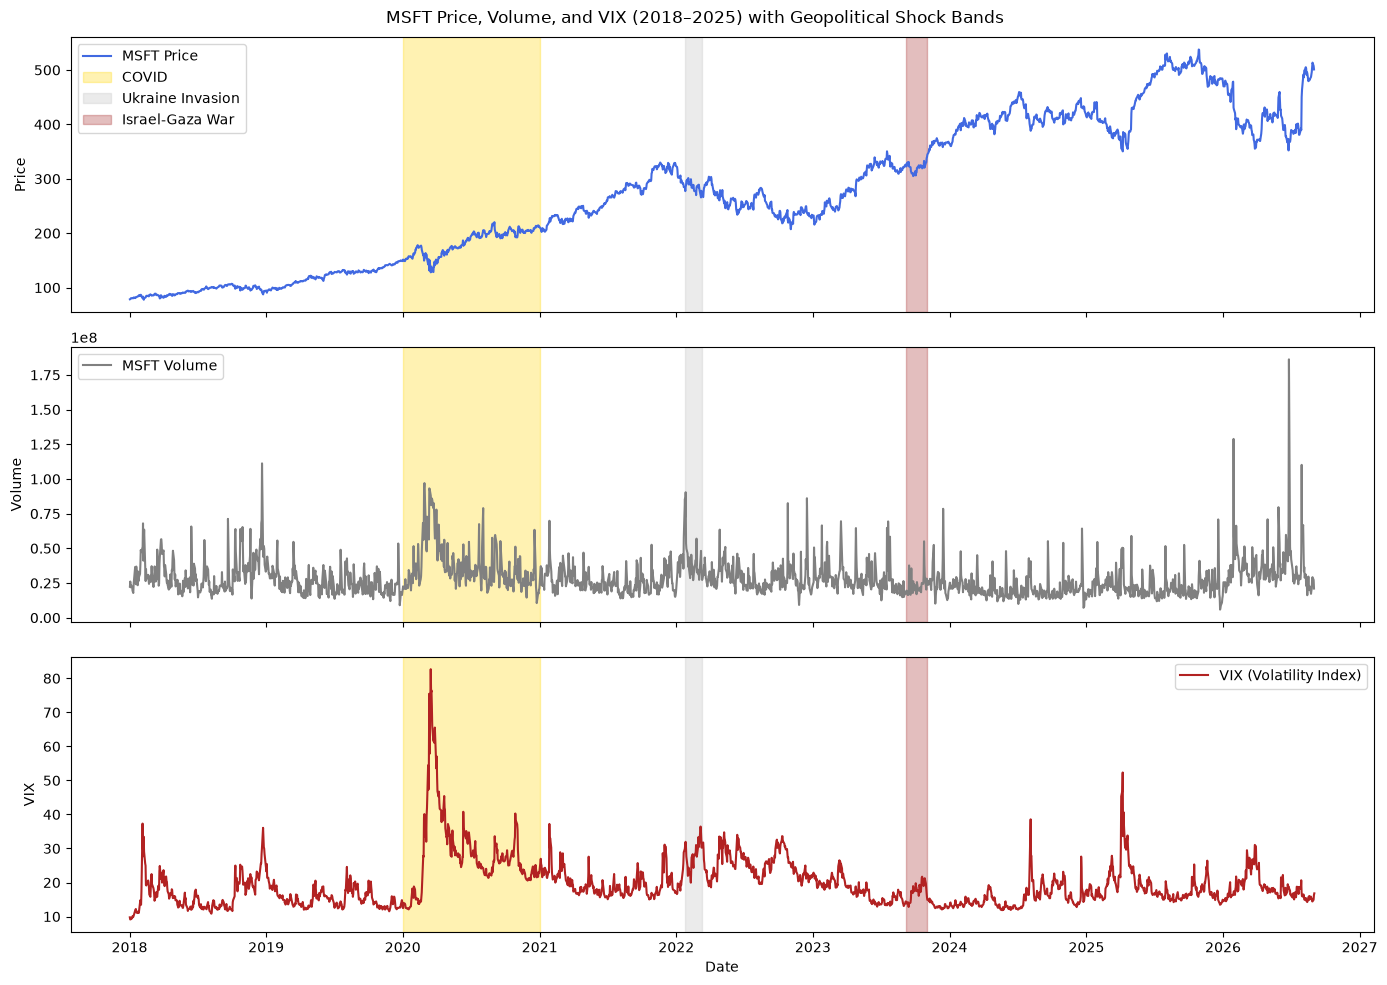

In [55]:
event_bands = [
    ("2020-01-01", "2021-01-01", "COVID"),
    ("2022-01-24", "2022-03-10", "Ukraine Invasion"),
    ("2023-09-07", "2023-11-01", "Israel-Gaza War"),
]

# Download VIX (CBOE volatility index)
# vix = yf.download("^VIX", start="2018-01-01", end="2025-02-28")
vix = yf.download("^VIX", start="2018-01-01")

# Plot MSFT price, volume, and VIX
fig, axs = plt.subplots(3, figsize=(14, 10), sharex=True)
fig.suptitle("MSFT Price, Volume, and VIX (2018–2025) with Geopolitical Shock Bands")

# Price plot
axs[0].plot(
    df_filtered.index, df_filtered["Close"], label="MSFT Price", color="royalblue"
)
axs[0].set_ylabel("Price")
axs[0].legend()

# Volume plot
axs[1].plot(df_filtered.index, df_filtered["Volume"], label="MSFT Volume", color="gray")
axs[1].set_ylabel("Volume")
axs[1].legend()

# VIX plot
axs[2].plot(vix.index, vix["Close"], label="VIX (Volatility Index)", color="firebrick")
axs[2].set_ylabel("VIX")
axs[2].legend()
axs[2].set_xlabel("Date")

# Highlight events with distinct colors
colorv = ["gold", "silver", "brown"]
for i, (start, end, label) in enumerate(event_bands):
    for ax in axs:
        ax.axvspan(
            pd.to_datetime(start),
            pd.to_datetime(end),
            color=colorv[i % len(colorv)],
            alpha=0.3,
            label=label,
        )

# Remove duplicate labels in legend
handles, labels = axs[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
axs[0].legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

### Compare different assets

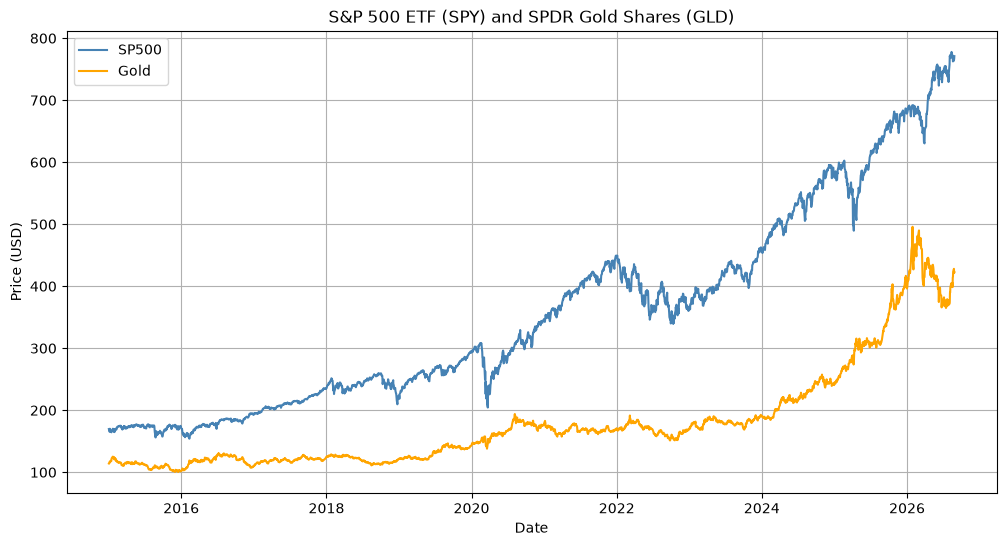

In [37]:
# Adding Moving Average indicators
# apple = yf.Ticker("UUP")
spy = yf.Ticker("SPY")
# apple = yf.Ticker("AAPL")
spy_df = spy.history(start="2015-01-01", end="2026-08-31")
gold = yf.Ticker("GLD")
# gold = yf.Ticker("TLT")
gold_df = gold.history(start="2015-01-01", end="2026-08-31")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(spy_df["Close"], label="SP500", color="steelblue")
plt.plot(gold_df["Close"], label="Gold", color="orange")
plt.title("S&P 500 ETF (SPY) and SPDR Gold Shares (GLD)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

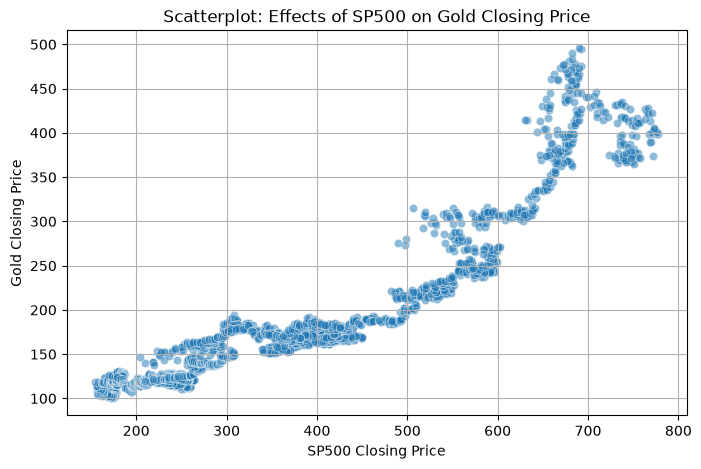

In [61]:
import seaborn as sns

# Scatterplot: Volume vs Log(Price)
plt.figure(figsize=(8, 5))
sns.scatterplot(y=gold_df["Close"], x=spy_df["Close"], alpha=0.5)
# sns.scatterplot(y=np.log(gold_df["Close"]), x=np.log(spy_df["Close"]), alpha=0.5)
plt.title("Scatterplot: Effects of SP500 on Gold Closing Price")
plt.ylabel("Gold Closing Price")
plt.xlabel("SP500 Closing Price")
plt.grid(True)
plt.show()

In [ ]:
# Combine SPY and Gold closing prices into a single dataframe, aligned by date
compare_df = pd.DataFrame({
    "SPY_Close": spy_df["Close"],
    "Gold_Close": gold_df["Close"],
}).dropna()

correlation = np.corrcoef(compare_df["SPY_Close"], np.log(compare_df["Gold_Close"]))[0, 1]
print(f"Correlation between Log(Gold Close) and SPY Close: {correlation:.2f}")

In [ ]:
## Gold price by SPY below/above median
# 1. Create a dummy
compare_df["Median SPY Dummy"] = np.where(
    compare_df["SPY_Close"] >= compare_df["SPY_Close"].median(), "Above", "Below"
)
# 2. Plot
plt.figure(figsize=(8, 5))
sns.kdeplot(data=compare_df, x="Gold_Close", hue="Median SPY Dummy", multiple="stack")
plt.title("Density Plot - Gold Price by SPY Median Regime")

From this descriptive analysis, how important would you say is the relationship between the S&P 500 (SPY) and the price of gold (GLD)?

### Estimate the parameters in the following TLR model:

$log(Gold_t) = \beta_0 + \beta_1 SPY_t + \beta_2 trend_t + u_t$  

In [74]:
# Let's create a trend variable
compare_df["trend"] = np.arange(1, len(compare_df) + 1)
compare_df["trend"]

Date
2015-01-02 00:00:00-05:00       1
2015-01-05 00:00:00-05:00       2
2015-01-06 00:00:00-05:00       3
2015-01-07 00:00:00-05:00       4
2015-01-08 00:00:00-05:00       5
                             ... 
2026-08-21 00:00:00-04:00    2926
2026-08-24 00:00:00-04:00    2927
2026-08-25 00:00:00-04:00    2928
2026-08-26 00:00:00-04:00    2929
2026-08-27 00:00:00-04:00    2930
Name: trend, Length: 2930, dtype: int64

### Simple Linear Regression
We start with a simple linear regression: Gold price explained by SPY price alone.

In [75]:
# Model
y = np.log(compare_df["Gold_Close"])
X = sm.add_constant(compare_df["SPY_Close"])
mdl1 = sm.OLS(y, X).fit()
mdl1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Gold_Close   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                 3.924e+04
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:50:10   Log-Likelihood:                 2615.8
No. Observations:                2930   AIC:                            -5228.
Df Residuals:                    2928   BIC:                            -5216.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3108      0.004    970.209      0.000       4.302       4.320
SPY_Close      0.0022   1.13e-05    198.096      0.000       0.002       0.002
==============================================================================
Omnibus:                      230.811   Durbin-Watson:                   0.017
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              286.950
Skew:                           0.733   Prob(JB):                     4.89e-63
Kurtosis:                       3.447   Cond. No.                         951.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Multiple Linear Regression
Now let's extend the model by adding `trend` as a second regressor, matching the full model specified above ($log(Gold_t) = \beta_0 + \beta_1 SPY_t + \beta_2 trend_t + u_t$). Comparing `mdl1` and `mdl2` shows how much the SPY coefficient (and the model's explanatory power) changes once we control for the underlying time trend.

In [76]:
# Multiple regression: SPY price + trend
X_multi = sm.add_constant(compare_df[["SPY_Close", "trend"]])
mdl2 = sm.OLS(y, X_multi).fit()
mdl2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Gold_Close   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                 1.993e+04
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:50:12   Log-Likelihood:                 2637.4
No. Observations:                2930   AIC:                            -5269.
Df Residuals:                    2927   BIC:                            -5251.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2963      0.005    871.523      0.000       4.287       4.306
SPY_Close      0.0025   3.67e-05     67.501      0.000       0.002       0.003
trend      -4.627e-05   7.01e-06     -6.604      0.000      -6e-05   -3.25e-05
==============================================================================
Omnibus:                      245.054   Durbin-Watson:                   0.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              309.637
Skew:                           0.754   Prob(JB):                     5.80e-68
Kurtosis:                       3.514   Cond. No.                     4.71e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.71e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### A Note on Spurious Regression: Price Levels vs. Returns
Both `SPY_Close` and `Gold_Close` are non-stationary series that trend upward over time for largely unrelated reasons (equity earnings growth vs. gold as an inflation hedge / dollar hedge). Two unrelated trending series can show a strong positive correlation in **levels** even without any genuine economic relationship — a classic case of *spurious regression*. The standard fix in empirical finance is to look at **returns** (percentage changes) instead of price levels, which removes the common trend.

In [77]:
# Compute daily returns instead of price levels
compare_df["SPY_ret"] = compare_df["SPY_Close"].pct_change()
compare_df["Gold_ret"] = compare_df["Gold_Close"].pct_change()

return_corr = compare_df[["SPY_ret", "Gold_ret"]].corr()
print(return_corr)

          SPY_ret  Gold_ret
SPY_ret   1.00000   0.06894
Gold_ret  0.06894   1.00000


Compare this correlation to the one computed earlier on price levels. If it's much smaller (or negative), that confirms the level-based correlation was largely driven by the shared upward trend rather than a genuine relationship between SPY and Gold — consistent with gold's usual role as a portfolio diversifier / safe haven rather than a fellow traveler of equities.

### Regime-Dependent Correlation: Down Days vs. Up Days
A near-zero *unconditional* correlation can still hide regime-dependent behavior. If gold acts as a safe haven, we might expect its relationship with SPY to look different on days when equities fall versus days when they rise — e.g. a more negative (or less positive) correlation specifically during SPY sell-offs, consistent with a "flight to safety."

In [78]:
# Split into days where SPY fell vs. rose, and check the correlation within each regime
down_days = compare_df[compare_df["SPY_ret"] < 0]
up_days = compare_df[compare_df["SPY_ret"] >= 0]

corr_down = down_days[["SPY_ret", "Gold_ret"]].corr().loc["SPY_ret", "Gold_ret"]
corr_up = up_days[["SPY_ret", "Gold_ret"]].corr().loc["SPY_ret", "Gold_ret"]

print(f"Correlation on SPY down days: {corr_down:.4f}")
print(f"Correlation on SPY up days:   {corr_up:.4f}")

Correlation on SPY down days: 0.0280
Correlation on SPY up days:   0.0904


This result runs against the naive "flight to safety" story: the correlation on down days (0.028) is even closer to zero than on up days (0.090), not more negative. Both are weak, so neither regime shows gold reliably moving with equities, but there's no clear evidence here of it moving against them on the average down day either.

### Tail-Risk Check: Gold on SPY's Worst Days
The safe-haven story is usually about severe sell-offs, not ordinary down days — most negative-return days are just mild noise with no particular reason for gold to react. A sharper test restricts to SPY's most extreme drops (e.g. its worst 5% of days) rather than every day with a negative return.

In [79]:
# Focus on the most severe SPY sell-off days (bottom 5% of returns) instead of all down days
threshold = compare_df["SPY_ret"].quantile(0.05)
crash_days = compare_df[compare_df["SPY_ret"] <= threshold]

corr_crash = crash_days[["SPY_ret", "Gold_ret"]].corr().loc["SPY_ret", "Gold_ret"]
print(f"Correlation on SPY's worst 5% of days: {corr_crash:.4f}")
print(f"Number of days in this tail: {len(crash_days)}")

Correlation on SPY's worst 5% of days: 0.2199
Number of days in this tail: 147


This result goes against the simple safe-haven story rather than confirming it. On SPY's worst days, gold correlates more positively with equities (0.22) than on an average day (0.07) or even on ordinary down days (0.03).
During acute crises, correlations across asset classes tend to rise, not fall — sometimes summarized as "in a crash, everything goes down together." 

### Conduct t-test statistics

In [ ]:
from scipy import stats

coef_spy = mdl1.params["SPY_Close"]
se_spy = mdl1.bse["SPY_Close"]
check_p = mdl1.pvalues.loc["SPY_Close"]

# Compute t-value
t_value = (coef_spy - 0) / se_spy
print(f"t-value: {t_value:.2f}")

# Compute critical value at 0.05 level
alpha = 0.05
cv = stats.t.ppf(1 - alpha, df=mdl1.df_resid)
print(f"Critical Value for {alpha} confidence level: {cv:.2f}")

# Compute pvalue
p = 1 - stats.t.cdf(abs(t_value), df=mdl1.df_resid)
print(f"p-value: {p:.10f}")
print(f"p-value: {check_p:.10f}")

### Confidence Intervals

In [ ]:
# 90% confidence interval
conf_int = mdl1.conf_int(alpha=0.10)
print("90% Confidence Interval for SPY coefficient:")
print(conf_int)

In [ ]:
conf_int.loc["SPY_Close"].items

In [ ]:
print("CIs for SPY: \n", conf_int.loc["SPY_Close"].values)

**Note:**    
95% of the so computed CIs would contain the true population parameters.

We are 90% confident that the true value of β1, the coefficient for SPY Close, lies within the interval printed above. We could also say, with 90% confidence, that a one-unit increase in the SPY closing price is associated with a change in the (log) Gold closing price by an amount between the interval values.

NB: if the confidence interval does not include zero, it's telling us that the effect of the covariate is statistically significant at the 90% confidence level.